# Process and visualize survey data

In [11]:
import pandas as pd
pilot_consent= pd.read_csv('C:/Users/lovel/Documents/PSYC201/Nummenmaa2013/data/pilotB/survey/Bodymap_consent_language_history_prolific_id_corrected.csv')

# drop the unused column heads
pilot_consent.drop([0,1], inplace=True)

# exclude data from preview mode
pilot_consent=pilot_consent[pilot_consent.DistributionChannel!="preview"]
pilot_consent=pilot_consent[~pilot_consent.userID.str.contains("test")]

n_total= len(pilot_consent)
pilot_consent

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Eng_expenv_4,Eng_expenv_5,Eng_expenv_6,userID,DeviceIdentifier,AoA_lang1,AoA_lang2,AoA_lang3,AoA_lang4,AoA_lang5
2,11/17/2025 16:57,11/17/2025 16:59,0,76.174.43.81,100,169,1,11/17/2025 16:59,R_3HqlqgmbdTdH98B,NaN,...,0,9,9,673d016e27ff008ac4175fb1,NaN,English,Spanish,Thai,NaN,NaN
3,11/17/2025 17:17,11/17/2025 17:21,0,67.247.48.197,100,251,1,11/17/2025 17:21,R_6pbVbwDOHLN1UxQ,NaN,...,0,0,0,5aecad0e75deca000162634c,NaN,English,NaN,NaN,NaN,NaN
4,11/17/2025 18:34,11/17/2025 18:46,0,151.213.48.138,100,754,1,11/17/2025 18:46,R_3fBEh6aKOhR8jlf,NaN,...,10,10,10,61bb392e40db417c1a138dcb,NaN,English,NaN,NaN,NaN,NaN


In [16]:
# get the list of participants from the drawing data
import os

base_path = r"C:/Users/lovel/Documents/PSYC201/Nummenmaa2013/data/pilotB/drawing_data/"

csv_counts = {}
duration= {}

# Loop through all items in the base directory
for item in os.listdir(base_path):
    dir_path = os.path.join(base_path, item)

    # Only process directories
    if os.path.isdir(dir_path):
        # Count CSV files inside this directory
        count = sum(1 for f in os.listdir(dir_path) if f.lower().endswith(".csv"))
        csv_counts[item] = count

        # Only process duration if participant has 7 trials (8 files including timestamp.csv)
        if count == 8:
            timestamp_path = os.path.join(dir_path, "timestamps.csv")

            if os.path.exists(timestamp_path):
                df = pd.read_csv(timestamp_path)

                # compute duration per trial (in milliseconds)
                df["duration_ms"] = df["submit_timestamp"] - df["start_timestamp"]

                # store as dictionary: {trial_id: duration}
                duration[item] = dict(zip(df["trial_id"], df["duration_ms"]))

# Print summary
print("CSV counts:", csv_counts)
print("Durations:", duration)

CSV counts: {'5aecad0e75deca000162634c': 8, '61bb392e40db417c1a138dzw': 8, '673d016e27ff008ac4175fb1': 8}
Durations: {'5aecad0e75deca000162634c': {4: 44686, 5: 33508, 1: 34611, 3: 16426, 6: 20467, 2: 26905}, '61bb392e40db417c1a138dzw': {6: 82214, 3: 227466, 2: 73537, 5: 58394, 1: 29419, 4: 31488}, '673d016e27ff008ac4175fb1': {1: 28032, 3: 16511, 5: 22383, 4: 39737, 6: 28750, 2: 20129}}


In [13]:
#create a new column whether or not the participant completed the drawing part of the experiment
for key, count in csv_counts.items():
    pilot_consent.loc[pilot_consent["userID"] == key, "Finished_drawing"] = "1" if count == 8 else "0"

In [20]:
# filter out unfinished ones
pilot_consent=pilot_consent[pilot_consent.Finished=="1"]
pilot_consent=pilot_consent[pilot_consent.Finished_drawing=="1"]

n_after_incomplete= len(pilot_consent)

#attention check screening
pilot_consent=pilot_consent[pilot_consent.Eng_langenv_4=="7 years"]
pilot_consent=pilot_consent[pilot_consent.Eng_learnev_5=="7"]

n_after_att_check= len(pilot_consent)

pilot_consent

# duration: participants who spent < 5 seconds in more than one trial
exclude_fast = []
for pid, trials in duration.items():
    too_fast = sum(d < 5000 for d in trials.values())
    if too_fast > 1:
        exclude_fast.append(pid)

pilot_consent = pilot_consent[~pilot_consent["userID"].isin(exclude_fast)]

n_after_duration_filter = len(pilot_consent)

pilot_consent

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Eng_expenv_5,Eng_expenv_6,userID,DeviceIdentifier,AoA_lang1,AoA_lang2,AoA_lang3,AoA_lang4,AoA_lang5,Finished_drawing
2,11/17/2025 16:57,11/17/2025 16:59,0,76.174.43.81,100,169,1,11/17/2025 16:59,R_3HqlqgmbdTdH98B,NaN,...,9,9,673d016e27ff008ac4175fb1,NaN,English,Spanish,Thai,NaN,NaN,1
3,11/17/2025 17:17,11/17/2025 17:21,0,67.247.48.197,100,251,1,11/17/2025 17:21,R_6pbVbwDOHLN1UxQ,NaN,...,0,0,5aecad0e75deca000162634c,NaN,English,NaN,NaN,NaN,NaN,1


                      Stage  N_Participants  N_Excluded
0                   Initial               3         0.0
1        After incompletion               2         1.0
2    After attention checks               2         0.0
3  After duration filtering               2         0.0
4                     Final               2         NaN


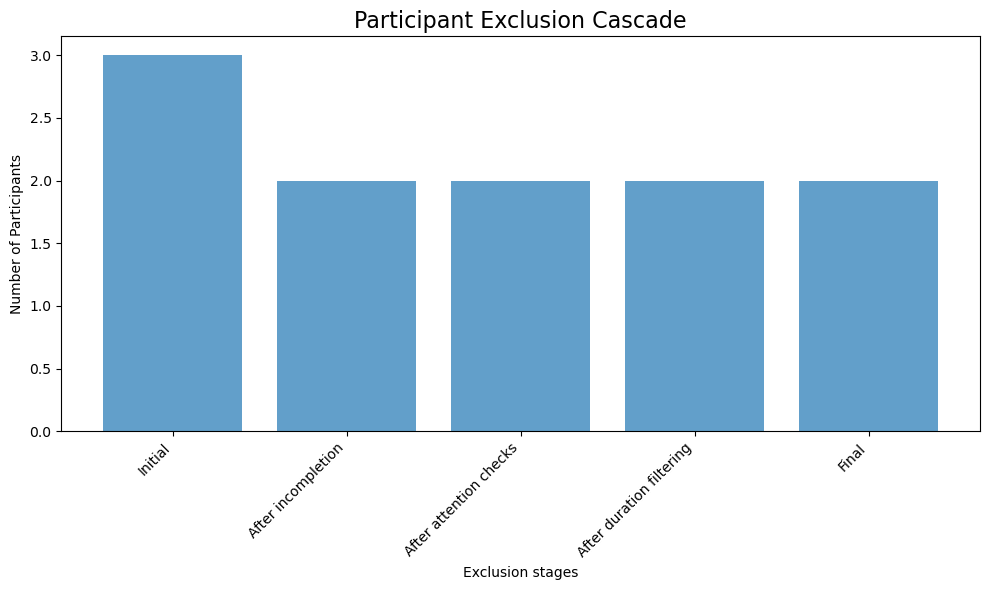

In [21]:
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# EXCLUSION SUMMARY TABLE
# -----------------------------
exclusion_summary = pd.DataFrame({
    "Stage": [
        "Initial",
        "After incompletion",
        "After attention checks",
        "After duration filtering",
        "Final"
    ],
    "N_Participants": [
        n_total,
        n_after_incomplete,
        n_after_att_check,
        n_after_duration_filter,   # <-- NEW
        n_after_duration_filter    # Final = same as after duration filtering
    ],
    "N_Excluded": [
        0,
        n_total - n_after_incomplete,
        n_after_incomplete - n_after_att_check,
        n_after_att_check - n_after_duration_filter,  # <-- NEW
        None
    ]
})


print(exclusion_summary)

plt.figure(figsize=(10, 6))

stages = exclusion_summary["Stage"]
counts = exclusion_summary["N_Participants"]

plt.bar(stages, counts, alpha=0.7)

plt.title("Participant Exclusion Cascade", fontsize=16)
plt.xlabel("Exclusion stages")
plt.ylabel("Number of Participants")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

